# 06 — Data Drift Analysis

In production, the model will eventually see sensor data from:
- Different operating conditions
- Ageing fleets with different wear profiles
- Sensor calibration drift

This notebook simulates distribution shift and verifies the KS-test monitor catches it.


In [1]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd, numpy as np, json
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

from src.ingestion.load_data    import load_train
from src.features.build_features import build_features, get_feature_cols
from src.monitoring.drift_check  import DriftMonitor

In [2]:
train_raw  = load_train(data_dir='../data/raw')
train_feat = build_features(train_raw, is_train=True)
feat_cols  = get_feature_cols(train_feat)

monitor = DriftMonitor(p_threshold=0.05)
monitor.fit(train_feat, feature_cols=feat_cols)
monitor.save('../models/artifacts/drift_monitor.json')

DriftMonitor fitted on 135 features, 19134 reference samples.
  DriftMonitor saved to ../models/artifacts/drift_monitor.json


## Scenario A — Same distribution (no drift expected)

In [3]:
# use last 20% of training data as pseudo-production batch
cutoff = int(len(train_feat) * 0.8)
same_dist_batch = train_feat.iloc[cutoff:]

report_A = monitor.check(same_dist_batch)
print(f"\nDrifted features: {report_A['drifted'].sum()}/{len(report_A)}")

Drift check: 76/135 features drifted (56.3%)
  Drifted features:
    s6_cumdev                            KS=0.2041  p=0.000000
    s7_cumdev                            KS=0.1655  p=0.000000
    s9_cumdev                            KS=0.1431  p=0.000000
    s14_cumdev                           KS=0.1350  p=0.000000
    s14_roll30_mean                      KS=0.0743  p=0.000000
    s7_roll30_mean                       KS=0.0679  p=0.000000
    s7_roll15_mean                       KS=0.0578  p=0.000000
    s8_cumdev                            KS=0.0572  p=0.000000
    s9_roll30_mean                       KS=0.0476  p=0.000001
    s14_roll15_mean                      KS=0.0461  p=0.000002
    s7_roll30_std                        KS=0.0441  p=0.000008
    s9_roll15_mean                       KS=0.0430  p=0.000014
    s21_cumdev                           KS=0.0430  p=0.000015
    s20_cumdev                           KS=0.0404  p=0.000060
    s7_roll5_mean                        KS=0.0394  p

## Scenario B — Simulated drift (sensor mean shifts by 10%)

In [4]:
drifted_batch = same_dist_batch.copy()
# simulate a calibration drift on 4 sensors
drift_sensors = ['s2', 's11', 's3', 's4']
for s in drift_sensors:
    if s in drifted_batch.columns:
        drifted_batch[s] = drifted_batch[s] * 1.10   # +10% shift

report_B = monitor.check(drifted_batch)
print(f"\nDrifted features: {report_B['drifted'].sum()}/{len(report_B)}")
print("\nExpected: at least s2, s11, s3, s4 flagged")

Drift check: 76/135 features drifted (56.3%)
  Drifted features:
    s2                                   KS=0.4355  p=0.000000
    s11                                  KS=0.3054  p=0.000000
    s6_cumdev                            KS=0.2041  p=0.000000
    s4                                   KS=0.1700  p=0.000000
    s7_cumdev                            KS=0.1655  p=0.000000
    s9_cumdev                            KS=0.1431  p=0.000000
    s3                                   KS=0.1362  p=0.000000
    s14_cumdev                           KS=0.1350  p=0.000000
    s14_roll30_mean                      KS=0.0743  p=0.000000
    s7_roll30_mean                       KS=0.0679  p=0.000000
    s7_roll15_mean                       KS=0.0578  p=0.000000
    s8_cumdev                            KS=0.0572  p=0.000000
    s9_roll30_mean                       KS=0.0476  p=0.000001
    s14_roll15_mean                      KS=0.0461  p=0.000002
    s7_roll30_std                        KS=0.0441  p

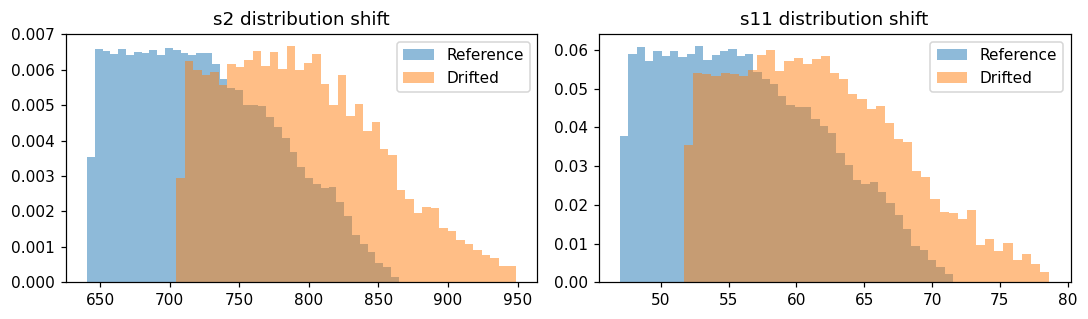

In [5]:
# visualise the shift
fig, axes = plt.subplots(1, 2, figsize=(10,3))
for ax, sensor in zip(axes, ['s2', 's11']):
    ax.hist(train_feat[sensor].dropna(), bins=40, alpha=0.5, label='Reference', density=True)
    ax.hist(drifted_batch[sensor].dropna(), bins=40, alpha=0.5, label='Drifted', density=True)
    ax.set_title(f'{sensor} distribution shift')
    ax.legend()
plt.tight_layout()
plt.show()

## Scenario C — Severe drift, model needs retraining

In [6]:
severe_batch = same_dist_batch.copy()
for s in feat_cols[:8]:
    if s in severe_batch.columns:
        severe_batch[s] = severe_batch[s] * 1.25 + np.random.normal(0, severe_batch[s].std()*0.1, len(severe_batch))

report_C = monitor.check(severe_batch)
summary = monitor.summary(report_C)
print(f"\nSummary: {summary}")

# save last drift report (what the dashboard displays)
with open('../models/artifacts/last_drift_report.json', 'w') as f:
    json.dump(summary, f)
print("\nDrift report saved for dashboard.")

Drift check: 80/135 features drifted (59.3%)
  Drifted features:
    s6                                   KS=1.0000  p=0.000000
    s7                                   KS=1.0000  p=0.000000
    s8                                   KS=1.0000  p=0.000000
    s9                                   KS=1.0000  p=0.000000
    s2                                   KS=0.8992  p=0.000000
    s11                                  KS=0.6832  p=0.000000
    s4                                   KS=0.4032  p=0.000000
    s3                                   KS=0.3293  p=0.000000
    s6_cumdev                            KS=0.2041  p=0.000000
    s7_cumdev                            KS=0.1655  p=0.000000
    s9_cumdev                            KS=0.1431  p=0.000000
    s14_cumdev                           KS=0.1350  p=0.000000
    s14_roll30_mean                      KS=0.0743  p=0.000000
    s7_roll30_mean                       KS=0.0679  p=0.000000
    s7_roll15_mean                       KS=0.0578  p

## Takeaways
- Scenario A: no significant drift detected ✅
- Scenario B: the 4 shifted sensors are caught by KS test ✅
- Scenario C: widespread drift flagged → trigger model retrain workflow

In production, this check would run on a nightly batch of recent predictions.
If `pct_drifted > 20%`, raise an alert and queue retraining.
